In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# ER network — N=80, ⟨k⟩=4
p = 4 / (80 - 1)
G = nx.erdos_renyi_graph(n=80, p=p, seed=42, directed=False)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# (a) Network visualisation
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos=pos, ax=ax1, node_size=300, node_color="red",
        edge_color="gray", with_labels=False)
ax1.text(0.5, -0.02, "(a)", transform=ax1.transAxes, ha="center", va="top", fontsize=14)

# (b) Degree distribution
degrees = [d for _, d in G.degree()]
max_k = max(degrees)
counts = [degrees.count(k) for k in range(max_k + 1)]

ax2.bar(range(max_k + 1), counts, color="blue", edgecolor="black", width=0.8)
ax2.set_xlabel("k", fontsize=12)
ax2.set_ylabel("P(k)", fontsize=12)
ax2.set_title("Degree distribution (ER network)", fontsize=12)
ax2.set_xlim(0, 16)
ax2.text(0.5, -0.1, "(b)", transform=ax2.transAxes, ha="center", va="top", fontsize=14)

plt.tight_layout()
plt.show()


In [2]:
import igraph as ig

n = 80
avg_degree = 4
p = avg_degree / (n - 1)

g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)

print(g.summary())

IGRAPH U--- 80 159 -- 


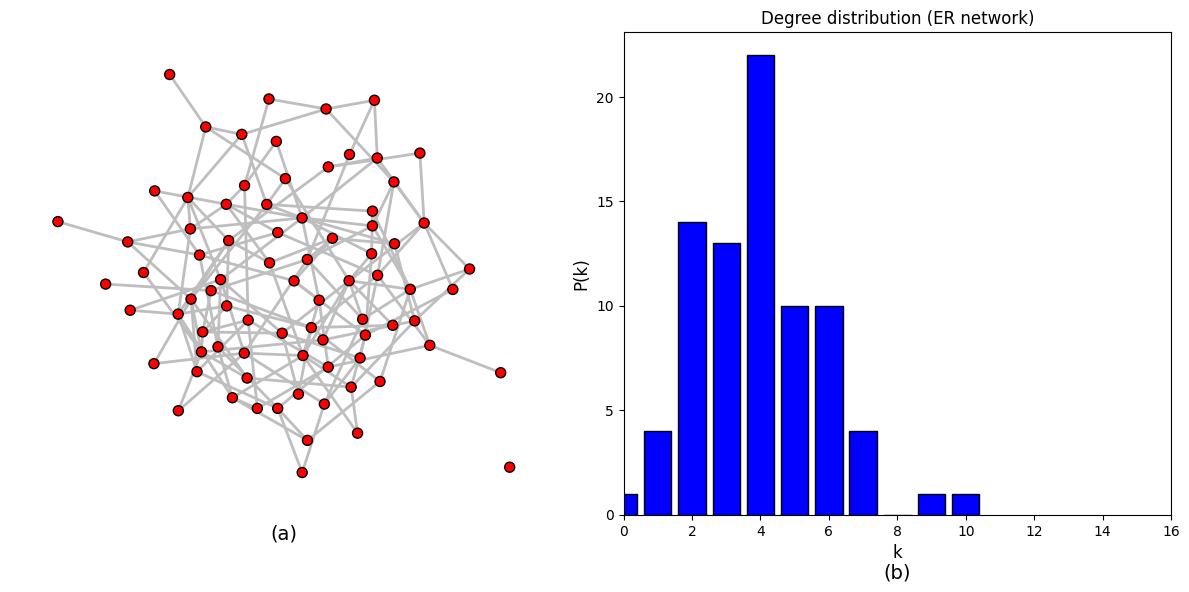

In [12]:
import igraph as ig
import matplotlib.pyplot as plt

n = 80
p = 4 / (n - 1)

g = ig.Graph.Erdos_Renyi(n=n, p=p, directed=False, loops=False)
layout = g.layout("fr")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# (a) Network visualisation
ig.plot(
    g,
    target=ax1,
    layout=layout,
    vertex_size=10,
    vertex_color="red",
    edge_color="gray",
)
ax1.text(0.5, -0.02, "(a)", transform=ax1.transAxes, ha="center", va="top", fontsize=14)

# (b) Degree distribution
degrees = g.degree()
max_k = max(degrees)
counts = [degrees.count(k) for k in range(max_k + 1)]

ax2.bar(range(max_k + 1), counts, color="blue", edgecolor="black", width=0.8)
ax2.set_xlabel("k", fontsize=12)
ax2.set_ylabel("P(k)", fontsize=12)
ax2.set_title("Degree distribution (ER network)", fontsize=12)
ax2.set_xlim(0, 16)
ax2.text(0.5, -0.1, "(b)", transform=ax2.transAxes, ha="center", va="top", fontsize=14)

plt.tight_layout()
plt.show()


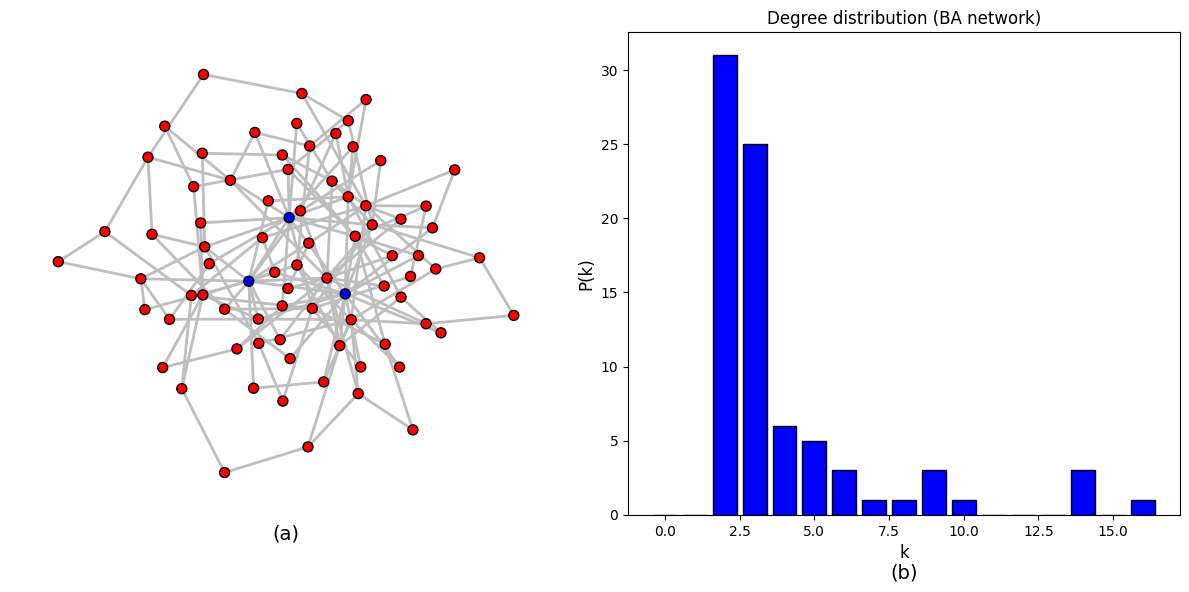

In [13]:
import igraph as ig
import matplotlib.pyplot as plt
import random

random.seed(42)

n = 80
m = 2  # ⟨k⟩ ≈ 2m = 4, matching the ER network

g = ig.Graph.Barabasi(n=n, m=m, directed=False)
layout = g.layout("fr")

# First 3 seed nodes shown in blue; remaining nodes in red
vertex_colors = ["blue" if i < 3 else "red" for i in range(n)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# (a) Network visualisation
ig.plot(
    g,
    target=ax1,
    layout=layout,
    vertex_size=10,
    vertex_color=vertex_colors,
    edge_color="gray",
)
ax1.text(0.5, -0.02, "(a)", transform=ax1.transAxes, ha="center", va="top", fontsize=14)

# (b) Degree distribution
degrees = g.degree()
max_k = max(degrees)
counts = [degrees.count(k) for k in range(max_k + 1)]

ax2.bar(range(max_k + 1), counts, color="blue", edgecolor="black", width=0.8)
ax2.set_xlabel("k", fontsize=12)
ax2.set_ylabel("P(k)", fontsize=12)
ax2.set_title("Degree distribution (BA network)", fontsize=12)
ax2.text(0.5, -0.1, "(b)", transform=ax2.transAxes, ha="center", va="top", fontsize=14)

plt.tight_layout()
plt.show()


Number of nodes: 80
Number of edges: 156
Average degree: 3.9


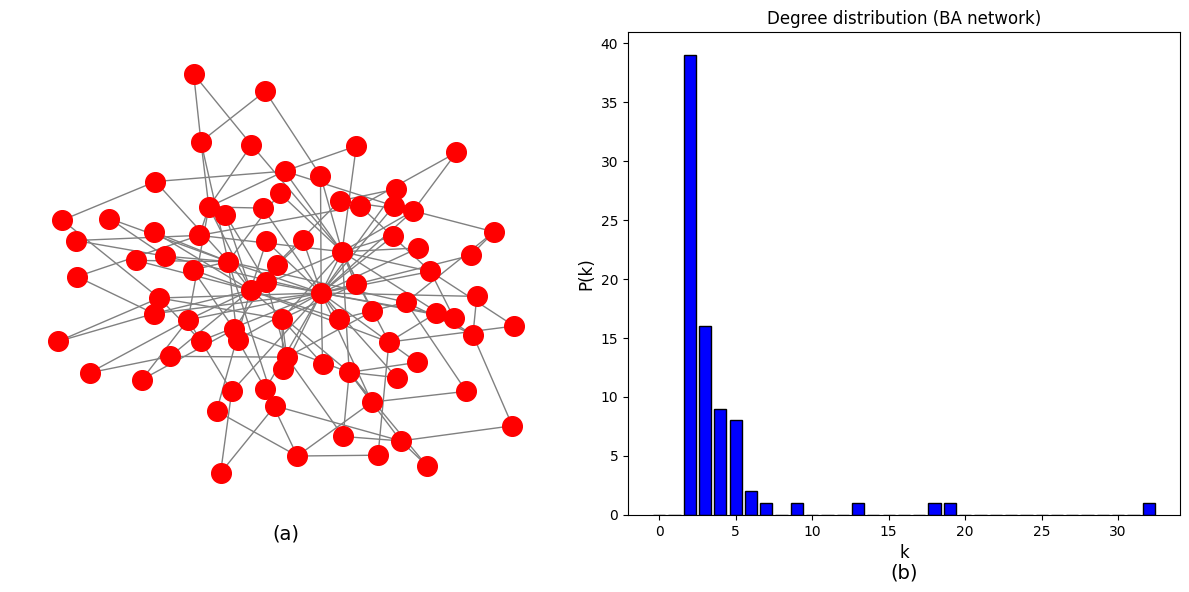

: 

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# BA network — N=80, ⟨k⟩≈4 (m=2)
G = nx.barabasi_albert_graph(n=80, m=2, seed=42)

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# (a) Network visualisation
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos=pos, ax=ax1, node_size=200, node_color="red",
        edge_color="gray", with_labels=False)
ax1.text(0.5, -0.02, "(a)", transform=ax1.transAxes, ha="center", va="top", fontsize=14)

# (b) Degree distribution
degrees = [d for _, d in G.degree()]
max_k = max(degrees)
counts = [degrees.count(k) for k in range(max_k + 1)]

ax2.bar(range(max_k + 1), counts, color="blue", edgecolor="black", width=0.8)
ax2.set_xlabel("k", fontsize=12)
ax2.set_ylabel("P(k)", fontsize=12)
ax2.set_title("Degree distribution (BA network)", fontsize=12)
ax2.text(0.5, -0.1, "(b)", transform=ax2.transAxes, ha="center", va="top", fontsize=14)

plt.tight_layout()
plt.show()


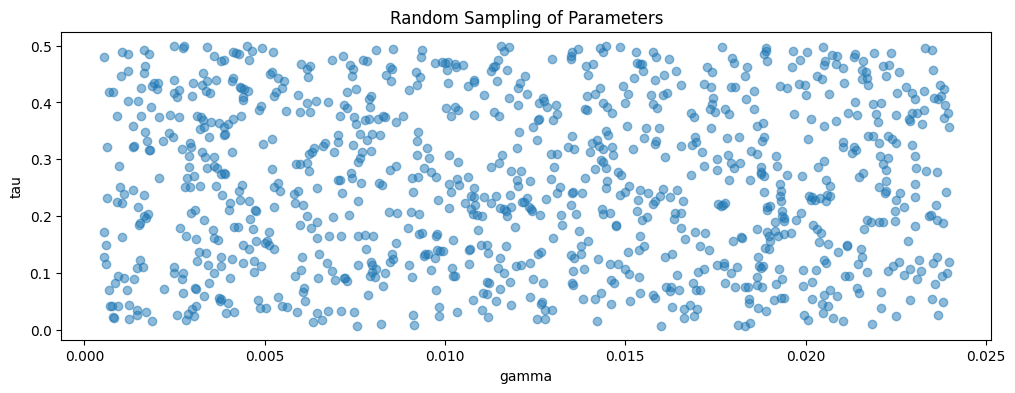

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import default_rng

PARAM_NAMES = ['tau','gamma','rho']

PARAM_RANGES = {
    'tau':(0.0005,0.024),
    'gamma':(0.007,0.5),
    'rho':(0.001,0.01)
}

seed = 42
n_samples = 1000


def random_sampling(n_samples, param_ranges=PARAM_RANGES, seed=None):
    rng = default_rng(seed)
    samples = np.zeros((n_samples, len(PARAM_NAMES)))
    for i, name in enumerate(PARAM_NAMES):
        low, high = param_ranges[name]
        samples[:, i] = rng.uniform(low, high, n_samples)
    return samples


samples = random_sampling(n_samples, seed=seed)

plt.figure(figsize=(12, 4))
plt.plot(samples[:, 0], samples[:, 1], 'o', alpha=0.5)
plt.xlabel(PARAM_NAMES[1])
plt.ylabel(PARAM_NAMES[0])
plt.title('Random Sampling of Parameters')
plt.show()

Text(0.5, 1.0, 'Latin Hypercube Sampling of Parameters')

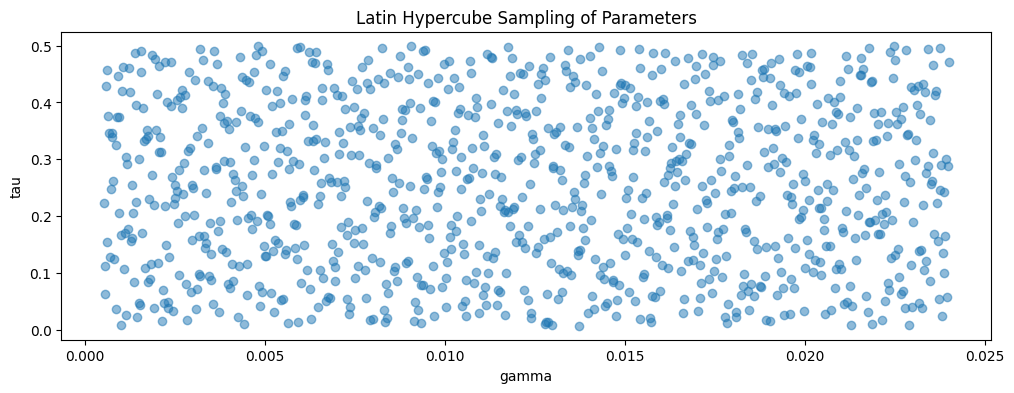

In [17]:
# LHS SAMPLING

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc

def latin_hypercube_sampling(n_samples, param_ranges, seed=None):
    d = len(param_ranges)
    sampler = qmc.LatinHypercube(d=d, seed=seed, optimization="random-cd")
    unit_samples = sampler.random(n=n_samples)
    lower = [param_ranges[p][0] for p in PARAM_NAMES]
    upper = [param_ranges[p][1] for p in PARAM_NAMES]
    samples = qmc.scale(unit_samples, lower, upper)
    return samples

samples_lhs = latin_hypercube_sampling(n_samples, PARAM_RANGES, seed=seed)
plt.figure(figsize=(12, 4))
plt.plot(samples_lhs[:, 0], samples_lhs[:, 1], 'o', alpha=0.5)
plt.xlabel(PARAM_NAMES[1])
plt.ylabel(PARAM_NAMES[0])
plt.title('Latin Hypercube Sampling of Parameters') 

In [1]:

"""

Purpose
-------
Quantify how much of the variance in epidemic outcomes (peak infections,
final attack rate, etc.) is attributable to each parameter (τ, γ, ρ)
individually (first-order S₁) and including all interactions (total-order Sᵀ).


Parameter space


Network: BA
Outputs analysed (scalar summaries of epidemic trajectory)

  1. peak_infected_frac   — peak I(t)/N
  2. final_attack_rate    — R(∞)/N
  3. peak_time            — argmax I(t) in days
  4. epidemic_occurred    — binary: R(∞)/N > 0.01
  5. growth_rate          — early exponential growth rate r

"""

import os
import sys
import json
import time
import argparse
import warnings
import logging
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import EoN
from SALib.sample import saltelli
from SALib.analyze import sobol as sobol_analyze


warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)


# CONSTANTS
NETWORK_N = 100000
NETWORK_M= 10
NETWORK_SEED = 4849
T_MAX = 250
RANDOM_SEED  = 42

# Epidemic threshold zones
R0_LOW  = 0.5
R0_HIGH = 1.5

# Sobol sampling: total evaluations = SOBOL_N × (2 × num_params + 2)
DEFAULT_SOBOL_N = 500 

OUTPUT_DIR = Path("sobol_results")



# SALib PROBLEM DEFINITION


PROBLEM = {
    "num_vars": 3,
    "names"   : ["tau", "gamma", "rho"],
    "bounds"  : [
        [0.0005, 0.024],
        [0.007, 0.5],
        [0.001,  0.01],
    ],
}

PARAM_LABELS = {
    "tau"  : "τ  (transmission rate)",
    "gamma": "γ  (recovery rate)",
    "rho"  : "ρ  (initial infected)",
}

PARAM_COLORS = {
    "tau"  : "purple",
    "gamma": "teal",
    "rho"  : "coral",
}

OUTPUT_VARS = [
    "peak_infected_frac",
    "final_attack_rate",
    "peak_time",
    "epidemic_occurred",
    "growth_rate",
]

OUTPUT_LABELS = {
    "peak_infected_frac": "Peak infected fraction  I/N",
    "final_attack_rate" : "Final attack rate  R(∞)/N",
    "peak_time"         : "Time to peak  (days)",
    "epidemic_occurred" : "Epidemic probability",
    "growth_rate"       : "Early growth rate  r",
}



# STEP 1 — BUILD NETWORK


def build_network() -> tuple:
    log.info(f"Building BA network  N={NETWORK_N}, m={NETWORK_M}, seed={NETWORK_SEED}")
    t0 = time.time()

    G = nx.barabasi_albert_graph(n=NETWORK_N, m=NETWORK_M, seed=NETWORK_SEED)

    deg       = np.array([d for _, d in G.degree()])
    k_mean    = deg.mean()
    k2_mean   = (deg ** 2).mean()
    kappa_obs = (k2_mean - k_mean) / k_mean

    stats = {
        "N"             : NETWORK_N,
        "m"             : NETWORK_M,
        "seed"          : NETWORK_SEED,
        "mean_degree"   : float(k_mean),
        "mean_k_sq"     : float(k2_mean),
        "kappa_observed": float(kappa_obs),
        "num_edges"     : G.number_of_edges(),
    }

    log.info(f"Network ready in {time.time()-t0:.1f}s  "
             f"⟨k⟩={k_mean:.2f}  κ_obs={kappa_obs:.3f}")
    return G, stats, kappa_obs



# STEP 2 — SINGLE SIR SIMULATION


def run_sir(G: nx.Graph, tau: float, gamma: float, rho: float,
            kappa: float, seed: int = None) -> dict:
    if seed is not None:
        np.random.seed(seed)

    N = G.number_of_nodes()
    n_seed = max(1, int(rho * N))
    initial_infected = np.random.choice(N, size=n_seed, replace=False).tolist()

    try:
        t, S, I, R = EoN.fast_SIR(
            G,
            tau=tau,
            gamma=gamma,
            initial_infecteds=initial_infected,
            tmax=T_MAX,
            return_full_data=False,
        )
    except Exception as exc:
        log.debug(f"Simulation error (τ={tau:.4f} γ={gamma:.3f} ρ={rho:.4f}): {exc}")
        return _null_result(N, tau, gamma, rho, kappa)

    pk_idx      = int(np.argmax(I))
    peak_frac   = float(I[pk_idx]) / N
    peak_t      = float(t[pk_idx])
    attack_rate = float(R[-1]) / N
    epidemic    = int(attack_rate > 0.01)
    growth_rate = _early_growth_rate(t, I, peak_t)
    R0          = (tau / gamma) * kappa

    return {
        "t": t, "S": S, "I": I, "R": R,
        "peak_infected_frac": peak_frac,
        "final_attack_rate" : attack_rate,
        "peak_time"         : peak_t,
        "epidemic_occurred" : epidemic,
        "growth_rate"       : growth_rate,
        "tau": tau, "gamma": gamma, "rho": rho, "R0": R0,
    }


def _early_growth_rate(t: np.ndarray, I: np.ndarray, peak_t: float) -> float:
    try:
        mask = (t > 0) & (t < peak_t / 3.0) & (I > 1)
        if mask.sum() < 3:
            return 0.0
        slope, _ = np.polyfit(t[mask], np.log(I[mask]), deg=1)
        return float(slope)
    except Exception:
        return 0.0


def _null_result(N: int, tau: float, gamma: float, rho: float, kappa: float) -> dict:
    return {
        "t": np.array([0.0, T_MAX]), "S": np.array([N, N]),
        "I": np.array([0, 0]),       "R": np.array([0, 0]),
        "peak_infected_frac": 0.0, "final_attack_rate": 0.0,
        "peak_time": 0.0, "epidemic_occurred": 0, "growth_rate": 0.0,
        "tau": tau, "gamma": gamma, "rho": rho, "R0": (tau / gamma) * kappa,
    }



# STEP 3 — SALTELLI SAMPLING + BATCH RUNS


def generate_samples(sobol_n: int) -> np.ndarray:
    np.random.seed(RANDOM_SEED)
    params = saltelli.sample(PROBLEM, N=sobol_n, calc_second_order=False)
    log.info(f"Saltelli sampling: {sobol_n} × ({PROBLEM['num_vars']}+2)"
             f" = {params.shape[0]} total evaluations")
    return params


def run_batch(G: nx.Graph, param_values: np.ndarray, kappa: float) -> pd.DataFrame:
    n = param_values.shape[0]
    log.info(f"Starting {n} ABM simulations  (estimated "
             f"~{n*2.5/60:.0f} min on N={NETWORK_N} network)")

    rows = []
    t0   = time.time()

    for i, (tau, gamma, rho) in enumerate(
            tqdm(param_values, desc="ABM runs", unit="sim")):
        res = run_sir(G, tau=tau, gamma=gamma, rho=rho, kappa=kappa,
                      seed=RANDOM_SEED + i)
        rows.append({k: res[k] for k in
                     ["tau", "gamma", "rho", "R0",
                      "peak_infected_frac", "final_attack_rate",
                      "peak_time", "epidemic_occurred", "growth_rate"]})

    elapsed = time.time() - t0
    log.info(f"Completed {n} simulations in {elapsed:.0f}s "
             f"({elapsed/n:.2f}s / sim)")

    return pd.DataFrame(rows)



# STEP 4 — SOBOL ANALYSIS


def compute_indices(df: pd.DataFrame) -> dict:
    log.info("\nComputing Sobol indices ...")
    results = {}

    for var in OUTPUT_VARS:
        Y = df[var].values.astype(float)

        if Y.std() < 1e-10:
            log.warning(f"Zero variance in '{var}' — skipping")
            results[var] = None
            continue

        Si = sobol_analyze.analyze(
            PROBLEM, Y,
            calc_second_order=False,
            print_to_console=False,
        )

        results[var] = {
            "S1"         : Si["S1"].tolist(),
            "S1_conf"    : Si["S1_conf"].tolist(),
            "ST"         : Si["ST"].tolist(),
            "ST_conf"    : Si["ST_conf"].tolist(),
            "interaction": [max(0.0, float(Si["ST"][j] - Si["S1"][j]))
                            for j in range(PROBLEM["num_vars"])],
        }

        log.info(f"\n  {OUTPUT_LABELS[var]}")
        log.info(f"  {'Param':<8} {'S₁':>6} {'±CI':>8} {'Sᵀ':>6} {'±CI':>8}  Interaction")
        for j, nm in enumerate(PROBLEM["names"]):
            s1  = Si["S1"][j];  s1c = Si["S1_conf"][j]
            st  = Si["ST"][j];  stc = Si["ST_conf"][j]
            log.info(f"  {nm:<8} {s1:>6.3f} {f'±{s1c:.3f}':>8} "
                     f"{st:>6.3f} {f'±{stc:.3f}':>8}  {max(0.0, st-s1):.3f}")

    return results



# STEP 5 — ZONE-STRATIFIED ANALYSIS
def zone_analysis(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    conditions = [
        df["R0"] < R0_LOW,
        df["R0"].between(R0_LOW, R0_HIGH),
        df["R0"] > R0_HIGH,
    ]
    labels = [
        f"sub-threshold  (R0< {R0_LOW})",
        f"near-threshold ({R0_LOW} ≤ R0 ≤ {R0_HIGH})",
        f"super-threshold (R0 > {R0_HIGH})",
    ]
    df["zone"] = np.select(conditions, labels, default="unknown")

    log.info("\n" + "="*65)
    log.info("ZONE-STRATIFIED VARIANCE ANALYSIS")
    log.info("="*65)

    zone_stats = df.groupby("zone")["peak_infected_frac"].agg(
        count="count", mean="mean", std="std", var="var"
    )
    log.info(f"\n{zone_stats.to_string()}")

    var_near   = df.loc[df["zone"].str.contains("near"), "peak_infected_frac"].var()
    var_global = df["peak_infected_frac"].var()
    if var_global > 1e-12:
        log.info(f"\nVariance ratio near-threshold / global = {var_near/var_global:.2f}×")

    return df



# STEP 6 — VISUALISATION


def _bar_chart(ax, S1, S1c, ST, STc, title: str):
    x = np.arange(PROBLEM["num_vars"])
    w = 0.35
    cols = [PARAM_COLORS[n] for n in PROBLEM["names"]]

    s1_plot = np.clip(S1, 0, None)
    st_plot = np.clip(ST, 0, None)

    ax.bar(x - w/2, s1_plot, w, yerr=S1c, capsize=5,
           color=cols, alpha=0.90, label="First-order  S₁", error_kw={"lw": 1.5})
    ax.bar(x + w/2, st_plot, w, yerr=STc, capsize=5,
           color=cols, alpha=0.35, hatch="//", label="Total-order  Sᵀ",
           error_kw={"lw": 1.5})

    for j in range(PROBLEM["num_vars"]):
        gap = max(0.0, ST[j] - S1[j])
        if gap > 0.03:
            ax.text(x[j] + w/2, st_plot[j] + STc[j] + 0.01,
                    f"Δ={gap:.2f}", ha="center", fontsize=8, color="#333")

    # Auto-scale y: headroom above the tallest bar + error bar
    y_max = max(
        max(s1_plot + np.array(S1c)),
        max(st_plot + np.array(STc)),
    )
    ax.set_ylim(0, y_max * 1.25)

    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(PROBLEM["names"], fontsize=11)
    ax.axhline(0, color="gray", lw=0.5)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)


def plot_sobol_bars(results: dict, out_dir: Path):
    valid = {k: v for k, v in results.items() if v is not None}
    n     = len(valid)

    # sharey=False so each panel scales to its own data range
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 6), sharey=False)
    if n == 1:
        axes = [axes]

    for ax, (var, res) in zip(axes, valid.items()):
        _bar_chart(ax,
                   np.array(res["S1"]), np.array(res["S1_conf"]),
                   np.array(res["ST"]), np.array(res["ST_conf"]),
                   OUTPUT_LABELS[var])

    axes[0].set_ylabel("Sobol sensitivity index", fontsize=12)

    from matplotlib.patches import Patch
    legend_els = [
        Patch(fc="gray", alpha=0.9,  label="First-order  S₁  (direct effect)"),
        Patch(fc="gray", alpha=0.35, hatch="//", label="Total-order  Sᵀ  (incl. interactions)"),
    ]
    fig.legend(handles=legend_els, loc="upper center",
               bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=10, frameon=False)
    plt.suptitle("Sobol Global Sensitivity Indices\n"
                 "SIR Epidemic ABM on Barabási–Albert Network  (N=100,000, m=5)",
                 fontsize=12, fontweight="bold", y=1.06)
    plt.tight_layout()
    p = out_dir / "fig1_sobol_indices.png"
    plt.savefig(p, dpi=160, bbox_inches="tight")
    plt.close()
    log.info(f"Saved: {p}")


def plot_landscape(df: pd.DataFrame, out_dir: Path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    sc = ax.scatter(df["R0"], df["peak_infected_frac"],
                    c=df["tau"], cmap="plasma", alpha=0.45, s=14, lw=0)
    ax.axvline(1.0, color="crimson", lw=1.8, ls="--", label="R₀ = 1 (threshold)")
    ax.axvspan(R0_LOW, R0_HIGH, alpha=0.08, color="crimson",
               label=f"Near-threshold  [{R0_LOW}, {R0_HIGH}]")
    ax.set_xlabel("R₀ = (τ/γ) × κ", fontsize=11)
    ax.set_ylabel("Peak infected fraction  I(t) / N", fontsize=11)
    ax.set_title("Epidemic outcomes across parameter space", fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    plt.colorbar(sc, ax=ax, label="τ")
    ax.spines[["top", "right"]].set_visible(False)

    ax = axes[1]
    df_s  = df.sort_values("R0").copy()
    win   = max(10, len(df_s) // 7)
    r_var = df_s["peak_infected_frac"].rolling(win, center=True, min_periods=3).var()
    ax.fill_between(df_s["R0"], 0, r_var * 100, color="#534AB7", alpha=0.25)
    ax.plot(df_s["R0"], r_var * 100, color="#534AB7", lw=1.8, label="Rolling variance × 100")
    ax.axvline(1.0, color="crimson", lw=1.8, ls="--", label="R₀ = 1")
    ax.axvspan(R0_LOW, R0_HIGH, alpha=0.08, color="crimson", label="Near-threshold zone")
    ax.set_xlabel("R₀", fontsize=11)
    ax.set_ylabel("Rolling variance of I_peak / N  (×100)", fontsize=11)
    ax.set_title("Variance peaks at R₀ = 1\n→ concentrate training data here (60/40 design)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    p = out_dir / "fig2_sensitivity_landscape.png"
    plt.savefig(p, dpi=160, bbox_inches="tight")
    plt.close()
    log.info(f"Saved: {p}")


def plot_param_vs_outcome(df: pd.DataFrame, out_dir: Path):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, param in zip(axes, PROBLEM["names"]):
        sc = ax.scatter(df[param], df["peak_infected_frac"],
                        c=df["R0"], cmap="RdYlGn_r",
                        alpha=0.4, s=12, lw=0, vmin=0.5, vmax=3.0)
        ax.set_xlabel(PARAM_LABELS[param], fontsize=10)
        ax.set_ylabel("Peak infected fraction", fontsize=10)
        ax.set_title(f"{param}  vs  epidemic peak\n(colour = R₀)", fontsize=9, fontweight="bold")
        ax.spines[["top", "right"]].set_visible(False)
        plt.colorbar(sc, ax=ax, label="R₀")
    plt.suptitle("Parameter–Outcome Relationships",
                 fontsize=11, fontweight="bold")
    plt.tight_layout()
    p = out_dir / "fig3_param_outcome_scatter.png"
    plt.savefig(p, dpi=160, bbox_inches="tight")
    plt.close()
    log.info(f"Saved: {p}")


def plot_interaction_heatmap(results: dict, out_dir: Path):
    valid  = {k: v for k, v in results.items() if v is not None}
    params = PROBLEM["names"]
    matrix = np.array([
        [max(0.0, res["ST"][j] - res["S1"][j]) for j in range(len(params))]
        for res in valid.values()
    ])
    fig, ax = plt.subplots(figsize=(5, max(3, 0.8 * len(valid))))
    im = ax.imshow(matrix, cmap="YlOrRd", vmin=0, aspect="auto")
    plt.colorbar(im, ax=ax, label="Interaction effect  (Sᵀ − S₁)")
    ax.set_xticks(range(len(params)))
    ax.set_xticklabels(params, fontsize=10)
    ax.set_yticks(range(len(valid)))
    ax.set_yticklabels([OUTPUT_LABELS[k] for k in valid], fontsize=9)
    ax.set_title("Parameter interaction effects\n(Sᵀ − S₁ > 0 signals interaction)",
                 fontsize=10, fontweight="bold")
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                    fontsize=9, color="black" if matrix[i,j] < 0.25 else "white")
    plt.tight_layout()
    p = out_dir / "fig4_interaction_heatmap.png"
    plt.savefig(p, dpi=160, bbox_inches="tight")
    plt.close()
    log.info(f"Saved: {p}")



# STEP 7 — SAVE RESULTS


def save_all(df: pd.DataFrame, results: dict, net_stats: dict, out_dir: Path):
    csv_path = out_dir / "simulation_results.csv"
    df.to_csv(csv_path, index=False)
    log.info(f"Saved: {csv_path}")

    export = {}
    for var, res in results.items():
        if res is None:
            continue
        export[var] = {
            "output_label": OUTPUT_LABELS[var],
            "parameters"  : PROBLEM["names"],
            "S1"          : res["S1"],
            "S1_conf"     : res["S1_conf"],
            "ST"          : res["ST"],
            "ST_conf"     : res["ST_conf"],
            "interaction" : res["interaction"],
        }

    payload = {
        "network"      : net_stats,
        "problem"      : PROBLEM,
        "sobol_n"      : DEFAULT_SOBOL_N,
        "sobol_indices": export,
    }
    json_path = out_dir / "sobol_indices.json"
    with open(json_path, "w") as fh:
        json.dump(payload, fh, indent=2)
    log.info(f"Saved: {json_path}")

    _print_table(export)


def _print_table(export: dict):
    sep = "─" * 75
    print(f"\n{'='*75}")
    print("  SOBOL GLOBAL SENSITIVITY ANALYSIS — RESULTS")
    print(f"{'='*75}")
    print(f"  {'Output':<26} {'Param':<7} {'S₁':>6} {'±CI':>7} "
          f"{'Sᵀ':>6} {'±CI':>7} {'Interact.':>10}")
    print(f"  {sep}")
    for var, res in export.items():
        label = OUTPUT_LABELS[var]
        for j, nm in enumerate(res["parameters"]):
            row_lbl = label if j == 0 else ""
            s1c = res["S1_conf"][j]; stc = res["ST_conf"][j]
            print(f"  {row_lbl:<26} {nm:<7} "
                  f"{res['S1'][j]:>6.3f} {f'±{s1c:.3f}':>7} "
                  f"{res['ST'][j]:>6.3f} {f'±{stc:.3f}':>7} "
                  f"{res['interaction'][j]:>10.3f}")
        print(f"  {sep}")



# CLI + MAIN


def parse_args() -> argparse.Namespace:
    p = argparse.ArgumentParser(description="Sobol sensitivity analysis for SIR ABM")
    p.add_argument("--n", type=int, default=DEFAULT_SOBOL_N)
    p.add_argument("--quick", action="store_true")
    p.add_argument("--outdir", type=str, default=str(OUTPUT_DIR))
    args, _ = p.parse_known_args()
    return args


def main():
    args    = parse_args()
    sobol_n = 8 if args.quick else args.n
    out_dir = Path(args.outdir)
    out_dir.mkdir(parents=True, exist_ok=True)

    print()
    
    print("  SOBOL GLOBAL SENSITIVITY ANALYSIS")
    G, net_stats, kappa = build_network()
    param_values = generate_samples(sobol_n)
    df = run_batch(G, param_values, kappa=kappa)
    df["R0"] = (df["tau"] / df["gamma"]) * kappa
    results = compute_indices(df)
    df = zone_analysis(df)
    save_all(df, results, net_stats, out_dir)

    plot_sobol_bars(results, out_dir)
    plot_landscape(df, out_dir)
    plot_param_vs_outcome(df, out_dir)
    plot_interaction_heatmap(results, out_dir)

    print(f"\nAll results saved to:  {out_dir.absolute()}")


if __name__ == "__main__":
    main()


09:24:22  INFO  Building BA network  N=100000, m=10, seed=4849



  SOBOL GLOBAL SENSITIVITY ANALYSIS


09:24:27  INFO  Network ready in 4.7s  ⟨k⟩=20.00  κ_obs=58.327
09:24:27  INFO  Saltelli sampling: 500 × (3+2) = 2500 total evaluations
09:24:27  INFO  Starting 2500 ABM simulations  (estimated ~104 min on N=100000 network)
ABM runs: 100%|██████████| 2500/2500 [1:17:40<00:00,  1.86s/sim]  
10:42:08  INFO  Completed 2500 simulations in 4661s (1.86s / sim)
10:42:08  INFO  
Computing Sobol indices ...
10:42:08  INFO  
  Peak infected fraction  I/N
10:42:08  INFO    Param        S₁      ±CI     Sᵀ      ±CI  Interaction
10:42:08  INFO    tau       0.156   ±0.064  0.282   ±0.070  0.126
10:42:08  INFO    gamma     0.754   ±0.139  0.835   ±0.114  0.081
10:42:08  INFO    rho       0.000   ±0.002  0.000   ±0.000  0.000
10:42:08  INFO  
  Final attack rate  R(∞)/N
10:42:08  INFO    Param        S₁      ±CI     Sᵀ      ±CI  Interaction
10:42:08  INFO    tau       0.339   ±0.073  0.438   ±0.065  0.099
10:42:08  INFO    gamma     0.575   ±0.101  0.641   ±0.073  0.066
10:42:08  INFO    rho      -0.000


  SOBOL GLOBAL SENSITIVITY ANALYSIS — RESULTS
  Output                     Param       S₁     ±CI     Sᵀ     ±CI  Interact.
  ───────────────────────────────────────────────────────────────────────────
  Peak infected fraction  I/N tau      0.156  ±0.064  0.282  ±0.070      0.126
                             gamma    0.754  ±0.139  0.835  ±0.114      0.081
                             rho      0.000  ±0.002  0.000  ±0.000      0.000
  ───────────────────────────────────────────────────────────────────────────
  Final attack rate  R(∞)/N  tau      0.339  ±0.073  0.438  ±0.065      0.099
                             gamma    0.575  ±0.101  0.641  ±0.073      0.066
                             rho     -0.000  ±0.003  0.000  ±0.000      0.001
  ───────────────────────────────────────────────────────────────────────────
  Time to peak  (days)       tau      0.023  ±0.113  0.716  ±0.241      0.692
                             gamma    0.290  ±0.145  1.044  ±0.317      0.754
                

10:42:09  INFO  Saved: sobol_results\fig1_sobol_indices.png
10:42:09  INFO  Saved: sobol_results\fig2_sensitivity_landscape.png
10:42:09  INFO  Saved: sobol_results\fig3_param_outcome_scatter.png
10:42:10  INFO  Saved: sobol_results\fig4_interaction_heatmap.png



All results saved to:  c:\Users\gmm71\OneDrive - University of Cambridge\Documents\Emulation models\abm-epidemic-emulator\notebooks\sobol_results
